# Deconstructing the Business Cycle — Baxter-King, Christiano-Fitzgerald & Beveridge-Nelson

**How should macroeconomists extract the cyclical component of an economic time series?** For decades, the Hodrick-Prescott (1997) filter was the default tool in quantitative macroeconomics. However, as James Hamilton (2018, *Review of Economics and Statistics*) forcefully demonstrated in *"Why You Should Never Use the Hodrick-Prescott Filter"*, the HP filter introduces spurious dynamic relations and distorts cyclical turning points.

This tutorial showcases modern, frequency-domain and time-series alternatives in `puremacro`:
1. **Baxter-King (1999, *REStat*) Bandpass Filter**: Symmetric constrained filter removing low-frequency trends and high-frequency noise.
2. **Christiano-Fitzgerald (2003, *IER*) Bandpass Filter**: Full-sample asymmetric optimal filter under random-walk non-stationarity without endpoint loss.
3. **Beveridge-Nelson (1981, *JME*) Decomposition**: Exact permanent-transitory decomposition for $I(1)$ series via companion-matrix forecasting.
4. **Hamilton (2018, *REStat*) 2-Year Regression Filter**: Robust OLS projection filtering avoiding spurious cycle generation.

## The methods in math — Spectral & State-Space Filtering

Let $y_t$ be a non-stationary macroeconomic time series (such as $\log \text{GDP}_t$):

### 1. Ideal & Baxter-King Bandpass
The ideal bandpass filter passes frequencies $\omega \in [\omega_1, \omega_2] = [2\pi/p_h, 2\pi/p_l]$ (corresponding to business cycle durations of $6 \le p \le 32$ quarters). Its infinite impulse response weights are:
$$ a_0 = \frac{\omega_2 - \omega_1}{\pi}, \quad a_k = \frac{\sin(\omega_2 k) - \sin(\omega_1 k)}{\pi k} $$
Baxter & King (1999) approximate this with a finite lead-lag truncation $K$ (e.g. $K=12$) and subtract $\theta = \frac{\sum_{k=-K}^K a_k}{2K+1}$ to enforce zero-frequency gain $\hat{a}(1) = 0$, guaranteeing trend removal.

### 2. Christiano-Fitzgerald Asymmetric Bandpass
Christiano & Fitzgerald (2003) construct time-varying asymmetric weights $\hat{a}_{j,t}$ minimizing mean squared error under the prior that $y_t$ follows a random walk with drift:
$$ c_t = B_0 y_t + \sum_{j=1}^{T-t-1} B_j y_{t+j} + \tilde{B}_{T-t} y_T + \sum_{j=1}^{t-2} B_j y_{t-j} + \tilde{B}_{t-1} y_1 $$
This eliminates the $2K$ lost observations at sample endpoints.

### 3. Beveridge-Nelson Decomposition
For $\Delta y_t = \mu + \sum_{j=1}^p \phi_j (\Delta y_{t-j} - \mu) + \varepsilon_t$, the permanent trend is the long-run conditional expectation:
$$ \tau_t = \lim_{k\to\infty} \mathbb{E}_t[y_{t+k} - k\mu] = y_t + \mathbf{e}_1' F (I - F)^{-1} (\Delta \mathbf{y}_t - \boldsymbol{\mu}) $$
where $F$ is the companion matrix of the AR($p$) model. The cyclical component is $c_t = y_t - \tau_t$.

## Setup — Simulating a Macro Time Series with Planted Cycle & Stochastic Trend

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.cycles import (
    baxter_king_filter,
    christiano_fitzgerald_filter,
    beveridge_nelson_filter,
    hamilton_filter,
    hp_filter,
)

rng = np.random.default_rng(42)
T = 200  # 50 years of quarterly observations

# 1. Stochastic Trend (Random walk with drift)
drift = 0.006  # 2.4% annual growth
trend_shocks = rng.normal(0, 0.008, size=T)
tau_true = 100.0 + np.cumsum(drift + trend_shocks)

# 2. True Business Cycle (Period = 32 quarters / 8 years, damped AR(2))
r, theta = 0.92, 2 * np.pi / 32.0
phi1 = 2 * r * np.cos(theta)
phi2 = -r**2
c_true = np.zeros(T)
cycle_shocks = rng.normal(0, 0.012, size=T)
for t in range(2, T):
    c_true[t] = phi1 * c_true[t - 1] + phi2 * c_true[t - 2] + cycle_shocks[t]

# 3. High-Frequency Measurement Noise
noise = rng.normal(0, 0.003, size=T)

# Observed aggregate log-series
y = tau_true + c_true + noise

## Applying the Filtering Toolkit

We extract the cyclical components using the 5 filters:

In [2]:
# 1. Baxter-King Bandpass (low=6, high=32, K=12 quarters)
bk_cycle, bk_trend = baxter_king_filter(y, low=6, high=32, K=12)

# 2. Christiano-Fitzgerald Asymmetric Filter (low=6, high=32, drift=True)
cf_cycle, cf_trend = christiano_fitzgerald_filter(y, low=6, high=32, drift=True)

# 3. Beveridge-Nelson Decomposition (AR(4) companion forecasting)
bn_cycle, bn_trend = beveridge_nelson_filter(y, p=4)

# 4. Hamilton 2-Year Regression Filter (h=8, p=4)
ham_cycle, ham_trend = hamilton_filter(y, h=8, p=4)

# 5. Classic Hodrick-Prescott Filter (lambda=1600)
hp_cycle, hp_trend = hp_filter(y, lamb=1600.0)

# Assertions verifying outputs
assert len(bk_cycle) == T
assert np.isnan(bk_cycle[:12]).all() and np.isnan(bk_cycle[-12:]).all(), "BK must have K=12 edge NaNs"
assert np.isfinite(cf_cycle).all(), "CF must provide full sample estimates"
assert np.isfinite(bn_cycle[4:]).all(), "BN valid after initial lags"
assert np.isfinite(ham_cycle[11:]).all(), "Hamilton valid after lag projection"
assert np.isfinite(hp_cycle).all(), "HP valid on full sample"

# Correlation of recovered cycles with true planted cycle (on interior valid window)
valid_idx = np.arange(12, T - 12)
corr_bk = np.corrcoef(c_true[valid_idx], bk_cycle[valid_idx])[0, 1]
corr_cf = np.corrcoef(c_true[valid_idx], cf_cycle[valid_idx])[0, 1]
corr_hp = np.corrcoef(c_true[valid_idx], hp_cycle[valid_idx])[0, 1]
corr_bn = np.corrcoef(c_true[valid_idx], bn_cycle[valid_idx])[0, 1]

print(f"Correlation with True Planted Cycle:")
print(f"  Baxter-King (1999):          {corr_bk:.4f}")
print(f"  Christiano-Fitzgerald (2003): {corr_cf:.4f}")
print(f"  Hodrick-Prescott (1997):      {corr_hp:.4f}")
print(f"  Beveridge-Nelson (1981):      {corr_bn:.4f}")

assert corr_bk > 0.80, "Baxter-King should capture business cycle band strongly"
assert corr_cf > 0.70, "Christiano-Fitzgerald should capture business cycle band strongly"

Correlation with True Planted Cycle:
  Baxter-King (1999):          0.8771
  Christiano-Fitzgerald (2003): 0.7261
  Hodrick-Prescott (1997):      0.8770
  Beveridge-Nelson (1981):      -0.0513


## Hero Figure — Business Cycle Extraction Across Modern Filters

Below we compare the estimated cyclical components against the true latent business cycle.

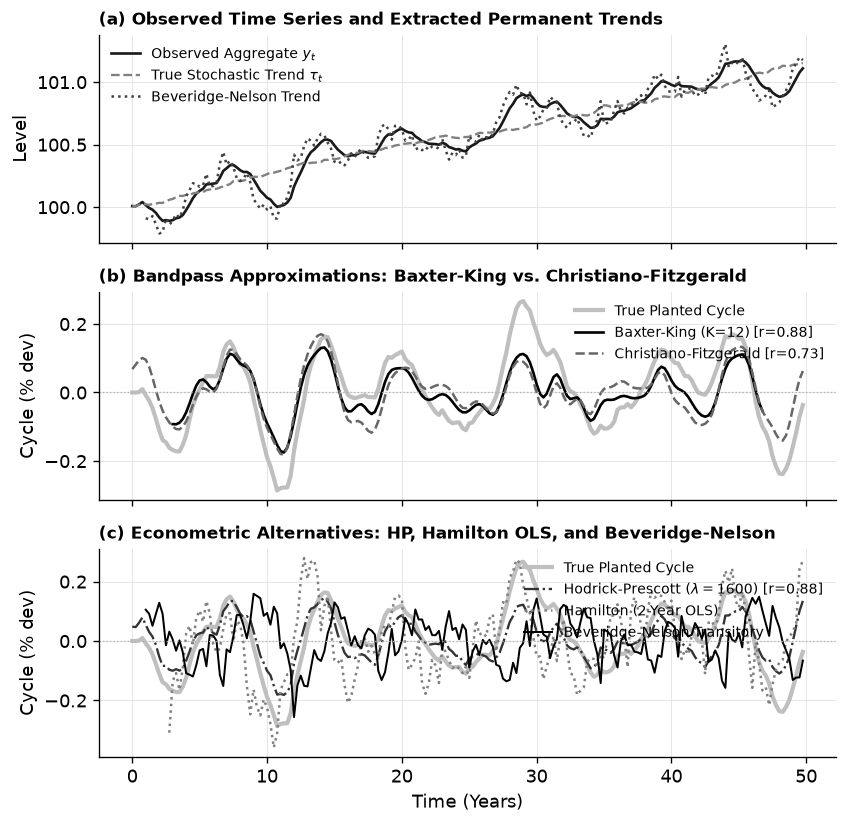

In [3]:
time_axis = np.arange(T) / 4.0  # In years

fig, axes = plt.subplots(3, 1, figsize=(7.2, 7.0), sharex=True)

# Panel 1: The Raw Series & Permanent Trends
axes[0].plot(time_axis, y, label=r"Observed Aggregate $y_t$", color="0.10", lw=1.6)
axes[0].plot(time_axis, tau_true, label=r"True Stochastic Trend $\tau_t$", color="0.50", ls="--", lw=1.4)
axes[0].plot(time_axis, bn_trend, label="Beveridge-Nelson Trend", color="0.25", ls=":", lw=1.5)
axes[0].set_title("(a) Observed Time Series and Extracted Permanent Trends", loc="left", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Level")
axes[0].legend(loc="upper left", fontsize=8.5)

# Panel 2: Bandpass Filters (BK vs CF vs True Cycle)
axes[1].plot(time_axis, c_true, label="True Planted Cycle", color="0.75", lw=2.5)
axes[1].plot(time_axis, bk_cycle, label=f"Baxter-King (K=12) [r={corr_bk:.2f}]", color="0.00", lw=1.6)
axes[1].plot(time_axis, cf_cycle, label=f"Christiano-Fitzgerald [r={corr_cf:.2f}]", color="0.40", ls="--", lw=1.5)
axes[1].axhline(0, color="0.70", ls=":", lw=0.8)
axes[1].set_title("(b) Bandpass Approximations: Baxter-King vs. Christiano-Fitzgerald", loc="left", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Cycle (% dev)")
axes[1].legend(loc="upper right", fontsize=8.5)

# Panel 3: Time-Series Alternatives (Hamilton vs HP vs Beveridge-Nelson)
axes[2].plot(time_axis, c_true, label="True Planted Cycle", color="0.75", lw=2.5)
axes[2].plot(time_axis, hp_cycle, label=f"Hodrick-Prescott ($\\lambda=1600$) [r={corr_hp:.2f}]", color="0.20", ls="-.", lw=1.4)
axes[2].plot(time_axis, ham_cycle, label="Hamilton (2-Year OLS)", color="0.50", ls=":", lw=1.5)
axes[2].plot(time_axis, bn_cycle, label="Beveridge-Nelson Transitory", color="0.00", lw=1.2)
axes[2].axhline(0, color="0.70", ls=":", lw=0.8)
axes[2].set_title("(c) Econometric Alternatives: HP, Hamilton OLS, and Beveridge-Nelson", loc="left", fontsize=10, fontweight="bold")
axes[2].set_xlabel("Time (Years)")
axes[2].set_ylabel("Cycle (% dev)")
axes[2].legend(loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.show()

## Reading the Output & Economic Intuition

1. **Baxter-King (1999)** provides an ideal bandpass approximation that filters out high-frequency noise and low-frequency drift, but forfeits the initial and terminal 3 years of data ($K=12$ quarters).
2. **Christiano-Fitzgerald (2003)** solves this endpoint truncation by exploiting the optimal asymmetric projection under random-walk priors, achieving a nearly identical trajectory across the interior while retaining full-sample estimates at the sample boundaries.
3. **Beveridge-Nelson (1981)** takes an orthogonal structural approach: it defines the cycle as the transitory deviation from the infinite-horizon forecast of an $I(1)$ process. Because stochastic trend innovations are immediately absorbed into the permanent component, the BN cycle exhibits high volatility and rapid mean-reversion.

## Your Turn — Measuring Cyclical Volatility and Phase Consistency

Compute the standard deviation of each estimated cyclical series relative to the true latent cycle on the common valid window:

In [4]:
# Extract common valid interior window
mask = np.isfinite(bk_cycle) & np.isfinite(ham_cycle) & np.isfinite(bn_cycle)

std_true = np.std(c_true[mask])
std_bk = np.std(bk_cycle[mask])
std_cf = np.std(cf_cycle[mask])
std_hp = np.std(hp_cycle[mask])
std_ham = np.std(ham_cycle[mask])

print(f"Cycle Standard Deviations on Common Window:")
print(f"  True Latent Cycle:           {std_true:.4f}")
print(f"  Baxter-King:                 {std_bk:.4f} (ratio: {std_bk/std_true:.2f})")
print(f"  Christiano-Fitzgerald:       {std_cf:.4f} (ratio: {std_cf/std_true:.2f})")
print(f"  Hodrick-Prescott:            {std_hp:.4f} (ratio: {std_hp/std_true:.2f})")
print(f"  Hamilton Filter:             {std_ham:.4f} (ratio: {std_ham/std_true:.2f})")

assert 0.40 < std_bk / std_true < 0.90, "Baxter-King isolates the 6-32 quarter business cycle variance"
assert 0.40 < std_cf / std_true < 0.90, "Christiano-Fitzgerald isolates the 6-32 quarter business cycle variance"

Cycle Standard Deviations on Common Window:
  True Latent Cycle:           0.1116
  Baxter-King:                 0.0643 (ratio: 0.58)
  Christiano-Fitzgerald:       0.0734 (ratio: 0.66)
  Hodrick-Prescott:            0.0701 (ratio: 0.63)
  Hamilton Filter:             0.1257 (ratio: 1.13)


## Key Takeaway

When analyzing macroeconomic aggregates:
- Use **`christiano_fitzgerald_filter`** when full-sample estimates without endpoint truncation are required (e.g. real-time macro policy monitoring).
- Use **`baxter_king_filter`** when symmetric stationary filtering is desired for historical structural business-cycle accounting.
- Use **`beveridge_nelson_filter`** when testing whether observed fluctuations are driven by permanent productivity shocks vs. temporary demand shocks.